<a href="https://colab.research.google.com/github/MayaUA21/TUGAS-AKHIR-MAYA/blob/main/Run%202%20(Non-CLAHE)/Patience%2010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RESIZE GAMBAR

In [ ]:
from PIL import Image
import os

input_folder = '/content/drive/MyDrive/TUGAS AKHIR MAYA/Datasets/Normal'
output_folder = '/content/drive/MyDrive/TUGAS AKHIR MAYA/Resized/Normal'
os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(input_folder):
    if filename.endswith('.png'):
        img = Image.open(os.path.join(input_folder, filename))
        img = img.resize((224, 224))
        img.save(os.path.join(output_folder, filename))

print("Selesai.")

Selesai.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Contrast Limited Adaptive Histogram Equalization

In [ ]:
!pip install opencv-python

In [ ]:
!pip install matplotlib

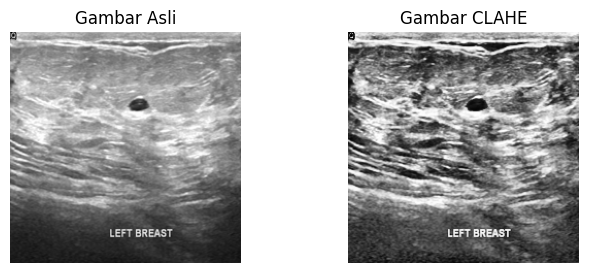

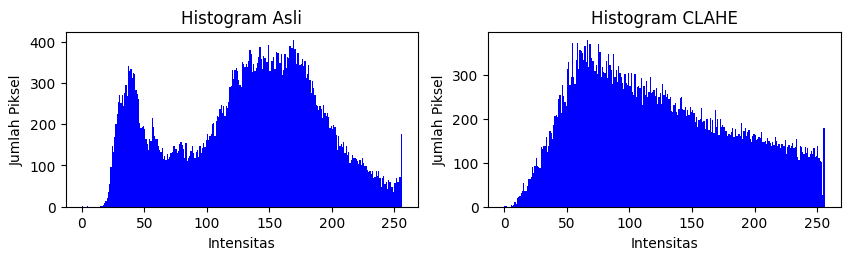

False

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Baca gambar
img = cv2.imread('/content/drive/MyDrive/TUGAS AKHIR MAYA/Resized/Benign/Benign (1).png', cv2.IMREAD_GRAYSCALE)

# Buat objek CLAHE
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(6,6))

# Terapkan CLAHE
clahe_img = clahe.apply(img)

# Gambar asli
plt.figure(figsize=(8,3))
plt.subplot(1,2,1)
plt.title('Gambar Asli')
plt.imshow(img, cmap='gray')
plt.axis('off')

# Gambar hasil CLAHE
plt.subplot(1,2,2)
plt.title('Gambar CLAHE')
plt.imshow(clahe_img, cmap='gray')
plt.axis('off')
plt.show()

# Histogram gambar asli
plt.figure(figsize=(10,5))
plt.subplot(2,2,1)
plt.title('Histogram Asli')
plt.hist(img.ravel(), bins=30, range=[0,256], color='blue')
plt.xlabel('Intensitas Warna')
plt.ylabel('Frekuensi')

# Histogram CLAHE
plt.subplot(2,2,2)
plt.title('Histogram CLAHE')
plt.hist(clahe_img.ravel(), bins=256, range=[0,256], color='blue')
plt.xlabel('Intensitas Warna')
plt.ylabel('Frekuensi')
plt.show()

cv2.imwrite('/content/drive/MyDrive/TUGAS AKHIR MAYA/CLAHE/6x6/Benign(1)/(3, 6x6).png', clahe_img)

Pembagian Dataset

In [ ]:
import os
import shutil
import random

folder_sumber = '/content/drive/MyDrive/TUGAS AKHIR MAYA/Resized'
folder_hasil = '/content/drive/MyDrive/TUGAS AKHIR MAYA/Pembagian datasets/Non-CLAHE'
os.makedirs(folder_hasil, exist_ok=True)

# RASIO PEMBAGIAN DATA

rasio_train = 0.70
rasio_val = 0.15
rasio_test = 0.15

# Nama kelas
kelas = ['Benign', 'Malignant', 'Normal']

# MEMBUAT FOLDER TRAIN VAL TEST

for bagian in ['train', 'val', 'test']:
    for nama_kelas in kelas:
        folder_tujuan = os.path.join(
            folder_hasil,
            bagian,
            nama_kelas
        )

        os.makedirs(folder_tujuan, exist_ok=True)

# PROSES PEMBAGIAN DATA

for nama_kelas in kelas:

    # Lokasi folder tiap kelas
    folder_kelas = os.path.join(
        folder_sumber,
        nama_kelas
    )

    # Mengambil semua gambar
    images = [
        f for f in os.listdir(folder_kelas)
        if os.path.isfile(os.path.join(folder_kelas, f))
    ]

    random.shuffle(images)
    total = len(images)
    jumlah_train = int(total * rasio_train)
    jumlah_val = int(total * rasio_val)

    # Pembagian dataset
    train_images = images[:jumlah_train]
    val_images = images[jumlah_train : jumlah_train + jumlah_val]
    test_images = images[jumlah_train + jumlah_val :]

    # MENYIMPAN GAMBAR KE FOLDER
    pembagian = {
        'train': train_images,
        'val': val_images,
        'test': test_images
    }

    for bagian, daftar_images in pembagian.items():
        folder_tujuan = os.path.join(folder_hasil, bagian, nama_kelas)
        for nama_file in daftar_images:
            sumber_file = os.path.join(folder_kelas, nama_file)
            tujuan_file = os.path.join(folder_tujuan, nama_file)
            shutil.copy2(sumber_file, tujuan_file)

print("Dataset berhasil dibagi menjadi train, val, dan test!")

Dataset berhasil dibagi menjadi train, val, dan test!


In [ ]:
from tensorflow.keras import backend as K
K.clear_session()

Deep Learning (1 tile size)

Found 210 images belonging to 3 classes.
Found 45 images belonging to 3 classes.


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_9[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

...


Epoch 4: finished saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5
7/7 - 16s - 2s/step - accuracy: 0.8667 - loss: 0.3283 - val_accuracy: 0.7556 - val_loss: 0.5434
Epoch 5/100

Epoch 5: val_loss improved from 0.54343 to 0.52301, saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5



Epoch 5: finished saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5
7/7 - 21s - 3s/step - accuracy: 0.9000 - loss: 0.2831 - val_accuracy: 0.8000 - val_loss: 0.5230
Epoch 6/100

Epoch 6: val_loss did not improve from 0.52301
7/7 - 16s - 2s/step - accuracy: 0.8857 - loss: 0.2841 - val_accuracy: 0.7778 - val_loss: 0.5805
Epoch 7/100

Epoch 7: val_loss did not improve from 0.52301
7/7 - 15s - 2s/step - accuracy: 0.9095 - loss: 0.2550 - val_accuracy: 0.7333 - val_loss: 0.5734
Epoch 8/100

Epoch 8: val_loss improved from 0.52301 to 0.48408, saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5



Epoch 8: finished saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5
7/7 - 17s - 2s/step - accuracy: 0.9429 - loss: 0.2077 - val_accuracy: 0.7556 - val_loss: 0.4841
Epoch 9/100

Epoch 9: val_loss improved from 0.48408 to 0.46641, saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5



Epoch 9: finished saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5
7/7 - 21s - 3s/step - accuracy: 0.9286 - loss: 0.1858 - val_accuracy: 0.8222 - val_loss: 0.4664
Epoch 10/100

Epoch 10: val_loss did not improve from 0.46641
7/7 - 16s - 2s/step - accuracy: 0.9619 - loss: 0.1395 - val_accuracy: 0.8000 - val_loss: 0.4787
Epoch 11/100

Epoch 11: val_loss did not improve from 0.46641
7/7 - 15s - 2s/step - accuracy: 0.9429 - loss: 0.1659 - val_accuracy: 0.7778 - val_loss: 0.4759
Epoch 12/100

Epoch 12: val_loss did not improve from 0.46641
7/7 - 15s - 2s/step - accuracy: 0.9286 - loss: 0.1818 - val_accuracy: 0.8000 - val_loss: 0.4800
Epoch 13/100

Epoch 13: val_loss did not improve from 0.46641
7/7 - 15s - 2s/step - accuracy: 0.9333 - loss: 0.1820 - val_accuracy: 0.7778 - val_loss: 0.5091
Epoch 14/100

Epoch 14: val_loss did not improve from 0.46641
7/7 - 16s - 2s/step - accuracy: 0.9667 - loss: 0.1151 - val_accuracy: 0.8000 - val_loss: 0.5261
Epoch


Epoch 17: finished saving model to /content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5
7/7 - 22s - 3s/step - accuracy: 0.9667 - loss: 0.1350 - val_accuracy: 0.8000 - val_loss: 0.4641
Epoch 18/100

Epoch 18: val_loss did not improve from 0.46414
7/7 - 16s - 2s/step - accuracy: 0.9714 - loss: 0.1197 - val_accuracy: 0.7556 - val_loss: 0.5176
Epoch 19/100

Epoch 19: val_loss did not improve from 0.46414
7/7 - 15s - 2s/step - accuracy: 0.9714 - loss: 0.1048 - val_accuracy: 0.7556 - val_loss: 0.5313
Epoch 20/100

Epoch 20: val_loss did not improve from 0.46414
7/7 - 16s - 2s/step - accuracy: 0.9762 - loss: 0.0833 - val_accuracy: 0.7778 - val_loss: 0.5138
Epoch 21/100

Epoch 21: val_loss did not improve from 0.46414
7/7 - 15s - 2s/step - accuracy: 0.9857 - loss: 0.0753 - val_accuracy: 0.7778 - val_loss: 0.5730
Epoch 22/100

Epoch 22: val_loss did not improve from 0.46414
7/7 - 20s - 3s/step - accuracy: 0.9476 - loss: 0.1134 - val_accuracy: 0.7556 - val_loss: 0.7352
Epoc

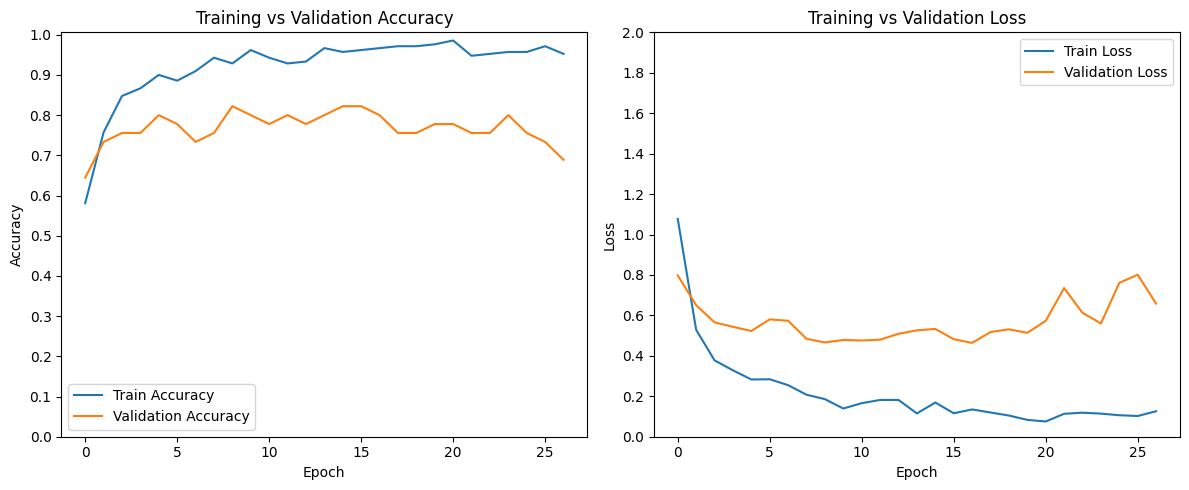

In [14]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# PATH DATASET
train_path = '/content/drive/MyDrive/TUGAS AKHIR MAYA/Pembagian datasets/Non-CLAHE/train'
val_path = '/content/drive/MyDrive/TUGAS AKHIR MAYA/Pembagian datasets/Non-CLAHE/val'

# AUGMENTASI
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range= 0.05,
    height_shift_range= 0.05,
    zoom_range= 0.1,
    horizontal_flip= True,
    vertical_flip= False,
    fill_mode= 'nearest')

#VALIDASI HANYA RESCALE
val_datagen = ImageDataGenerator(
    rescale=1./255
)

#LOAD DATA
train_data = datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_data = val_datagen.flow_from_directory(
    val_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# MOBILENETV2
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.summary()

# Bekukan layer base model
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
output = Dense(
    train_data.num_classes,
    activation='softmax'
)(x)

model = Model(inputs=base_model.input, outputs=output)

# KOMPILASI MODEL
model.compile(
    optimizer= Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# MENYIMPAN MODEL TERBAIK
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# TRAINING
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=[checkpoint, early_stop],
    verbose=2
)

# TABEL AKURASI DAN LOSS
Table = pd.DataFrame({
    'Epoch': range(1, len(history.history['accuracy']) + 1),
    'Train_Accuracy': history.history['accuracy'],
    'Val_Accuracy': history.history['val_accuracy'],
    'Train_Loss': history.history['loss'],
    'Val_Loss': history.history['val_loss']
})

print("\n=== TABEL AKURASI DAN LOSS PER EPOCH ===")
print(Table.to_string(index=False))

# PLOT GRAFIK AKURASI DAN LOSS
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(np.arange(0, len(history.history['accuracy'])+1, 5))     # Sumbu X: 0,5,10,...
plt.yticks(np.arange(0, 1.1, 0.1))             # Sumbu Y: 0.0,0.1,...,1.0
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(np.arange(0, len(history.history['loss'])+1, 5))     # Sumbu X: 0,5,10,...
plt.yticks(np.arange(0, 2.1, 0.2))
plt.legend()
plt.tight_layout()

plt.show()

CONFUSION MATRIK

Found 45 images belonging to 3 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step
Confusion Matrix
[[10  4  1]
 [ 3 12  0]
 [ 0  2 13]]


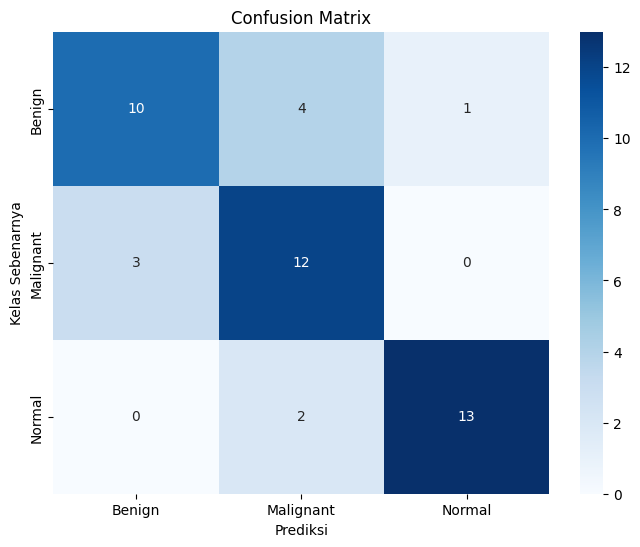


HASIL PERHITUNGAN MANUAL

Kelas : Benign
TP = 10
FP = 3
FN = 5
TN = 27
Accuracy  : 0.8222
Precision : 0.7692
Recall    : 0.6667
F1-Score  : 0.7143

Kelas : Malignant
TP = 12
FP = 6
FN = 3
TN = 24
Accuracy  : 0.8000
Precision : 0.6667
Recall    : 0.8000
F1-Score  : 0.7273

Kelas : Normal
TP = 13
FP = 1
FN = 2
TN = 29
Accuracy  : 0.9333
Precision : 0.9286
Recall    : 0.8667
F1-Score  : 0.8966

HASIL KESELURUHAN
Overall Accuracy : 0.7778


In [15]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

model_hasil = '/content/drive/MyDrive/TUGAS AKHIR MAYA/hasil/Non-CLAHE/bs32 (3)/model.h5'
model = load_model(model_hasil)

data_path = '/content/drive/MyDrive/TUGAS AKHIR MAYA/Pembagian datasets/Non-CLAHE/test'

eval_datagen = ImageDataGenerator(rescale=1./255)

test_generator = eval_datagen.flow_from_directory(
    data_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Prediksi Model
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

# Label sebenarnya
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

print("Confusion Matrix")
print(cm)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Prediksi")
plt.ylabel("Kelas Sebenarnya")
plt.title("Confusion Matrix")
plt.show()

# Perhitungan Manual

jumlah_data = np.sum(cm)

precision_total = 0
recall_total = 0
f1_total = 0

print("\n==============================")
print("HASIL PERHITUNGAN MANUAL")
print("==============================")

for i in range(len(class_labels)):

    TP = cm[i, i]
    FP = np.sum(cm[:, i]) - TP
    FN = np.sum(cm[i, :]) - TP
    TN = jumlah_data - TP - FP - FN

    # Accuracy
    accuracy = (TP + TN) / (TP + TN + FP + FN)

    # Precision
    if (TP + FP) != 0:
        precision = TP / (TP + FP)
    else:
        precision = 0

    # Recall
    if (TP + FN) != 0:
        recall = TP / (TP + FN)
    else:
        recall = 0

    # F1-Score
    if (precision + recall) != 0:
        f1 = (2 * precision * recall) / (precision + recall)
    else:
        f1 = 0

    precision_total += precision
    recall_total += recall
    f1_total += f1

    print(f"\nKelas : {class_labels[i]}")
    print(f"TP = {TP}")
    print(f"FP = {FP}")
    print(f"FN = {FN}")
    print(f"TN = {TN}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")

# Overall Accuracy
overall_accuracy = np.trace(cm) / np.sum(cm)

print("\n==============================")
print("HASIL KESELURUHAN")
print("==============================")

print(f"Overall Accuracy : {overall_accuracy:.4f}")